In [1]:
!pip install timm
!pip install grad-cam

import torch
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 71.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=a9d2a2e651f7efcf268a32d5644b3d5a4958bc074ac98adb2c9535ee8df6586a
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [3]:
import os
import kagglehub
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split


print("⏳ Sedang mendownload dataset baru dari Kaggle...")
download_path = kagglehub.dataset_download("fanconic/skin-cancer-malignant-vs-benign")
print(f"✅ Dataset berhasil diunduh ke: {download_path}")

if 'train' in os.listdir(download_path):
    train_dir = os.path.join(download_path, 'train')
elif 'data' in os.listdir(download_path):
    train_dir = os.path.join(download_path, 'data', 'train')
else:
    # Jika foldernya bersarang di dalam subfolder lain
    subfolders = [f for f in os.listdir(download_path) if os.path.isdir(os.path.join(download_path, f))]
    train_dir = os.path.join(download_path, subfolders[0], 'train')

print(f"📁 Mengarahkan PyTorch ke folder data yang benar: {train_dir}")


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


try:
    full_dataset = ImageFolder(root=train_dir, transform=transform)
    print(f"\n🎉 SUKSES! Dataset berhasil dimuat.")
    print(f"📊 Jumlah total gambar training: {len(full_dataset)}")
    print(f"🏷️ Kelas yang ditemukan: {full_dataset.classes}")

    # Pembagian data: 80% Training, 20% Validation
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_data, val_data = random_split(full_dataset, [train_size, val_size])

    # Variabel ini sekarang resmi terdefinisi di memori Colab
    train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
    print("🚀 train_loader dan val_loader SIAP digunakan!")

except Exception as e:
    print(f"❌ Terjadi kesalahan saat membaca folder: {e}")
    print(f"Isi asli folder download adalah: {os.listdir(download_path)}")

⏳ Sedang mendownload dataset baru dari Kaggle...
Using Colab cache for faster access to the 'skin-cancer-malignant-vs-benign' dataset.
✅ Dataset berhasil diunduh ke: /kaggle/input/skin-cancer-malignant-vs-benign
📁 Mengarahkan PyTorch ke folder data yang benar: /kaggle/input/skin-cancer-malignant-vs-benign/train

🎉 SUKSES! Dataset berhasil dimuat.
📊 Jumlah total gambar training: 2637
🏷️ Kelas yang ditemukan: ['benign', 'malignant']
🚀 train_loader dan val_loader SIAP digunakan!


In [ ]:
!file archive.zip

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import timm

# 1. Konfigurasi Device (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")

# 2. Memuat Arsitektur ReXNet-150 (num_classes=2 untuk Benign & Malignant)
model = timm.create_model('rexnet_150', pretrained=True, num_classes=2).to(device)

# 3. Parameter Pelatihan (Sesuai spesifikasi riset kamu)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
epochs = 5 # Kamu bisa menambah jumlah epoch ini nanti (misal: 10, 20, atau 25)

Menggunakan device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/39.2M [00:00<?, ?B/s]

In [5]:
import os
import kagglehub
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split


print("⏳ Sedang mendownload dataset baru dari Kaggle...")
download_path = kagglehub.dataset_download("fanconic/skin-cancer-malignant-vs-benign")
print(f"✅ Dataset berhasil diunduh ke: {download_path}")

if 'train' in os.listdir(download_path):
    train_dir = os.path.join(download_path, 'train')
elif 'data' in os.listdir(download_path):
    train_dir = os.path.join(download_path, 'data', 'train')
else:
    # Jika foldernya bersarang di dalam subfolder lain
    subfolders = [f for f in os.listdir(download_path) if os.path.isdir(os.path.join(download_path, f))]
    train_dir = os.path.join(download_path, subfolders[0], 'train')

print(f"📁 Mengarahkan PyTorch ke folder data yang benar: {train_dir}")


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


try:
    full_dataset = ImageFolder(root=train_dir, transform=transform)
    print(f"\n🎉 SUKSES! Dataset berhasil dimuat.")
    print(f"📊 Jumlah total gambar training: {len(full_dataset)}")
    print(f"🏷️ Kelas yang ditemukan: {full_dataset.classes}")

    # Pembagian data: 80% Training, 20% Validation
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_data, val_data = random_split(full_dataset, [train_size, val_size])

    # Variabel ini sekarang resmi terdefinisi di memori Colab
    train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
    print("🚀 train_loader dan val_loader SIAP digunakan!")

except Exception as e:
    print(f"❌ Terjadi kesalahan saat membaca folder: {e}")
    print(f"Isi asli folder download adalah: {os.listdir(download_path)}")

⏳ Sedang mendownload dataset baru dari Kaggle...
Using Colab cache for faster access to the 'skin-cancer-malignant-vs-benign' dataset.
✅ Dataset berhasil diunduh ke: /kaggle/input/skin-cancer-malignant-vs-benign
📁 Mengarahkan PyTorch ke folder data yang benar: /kaggle/input/skin-cancer-malignant-vs-benign/train

🎉 SUKSES! Dataset berhasil dimuat.
📊 Jumlah total gambar training: 2637
🏷️ Kelas yang ditemukan: ['benign', 'malignant']
🚀 train_loader dan val_loader SIAP digunakan!


In [6]:
# Wadah untuk menampung data grafik evaluasi
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

print("====== Memulai Proses Pelatihan ReXNet-150 ======\n")

for epoch in range(epochs):

    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass & Optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        # Hitung akurasi training
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = (correct_train / total_train) * 100

    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)


            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = (correct_val / total_val) * 100

    # Menyimpan semua hasil evaluasi ke dalam history
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    # Tampilkan log pencapaian epoch secara rapi
    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"   [TRAIN] Loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc:.2f}%")
    print(f"   [VALID] Loss: {epoch_val_loss:.4f} | Acc: {epoch_val_acc:.2f}%")
    print("-" * 50)

print("\n🎉 Proses Pelatihan Selesai dengan Sukses!")

====== Memulai Proses Pelatihan ReXNet-150 ======

Epoch [1/5]
   [TRAIN] Loss: 1.1105 | Acc: 76.58%
   [VALID] Loss: 0.7448 | Acc: 84.66%
--------------------------------------------------
Epoch [2/5]
   [TRAIN] Loss: 0.2620 | Acc: 92.60%
   [VALID] Loss: 0.6168 | Acc: 85.80%
--------------------------------------------------
Epoch [3/5]
   [TRAIN] Loss: 0.1091 | Acc: 96.30%
   [VALID] Loss: 0.7192 | Acc: 84.09%
--------------------------------------------------
Epoch [4/5]
   [TRAIN] Loss: 0.0751 | Acc: 97.39%
   [VALID] Loss: 0.5368 | Acc: 88.83%
--------------------------------------------------
Epoch [5/5]
   [TRAIN] Loss: 0.0650 | Acc: 98.10%
   [VALID] Loss: 0.5607 | Acc: 87.31%
--------------------------------------------------

🎉 Proses Pelatihan Selesai dengan Sukses!


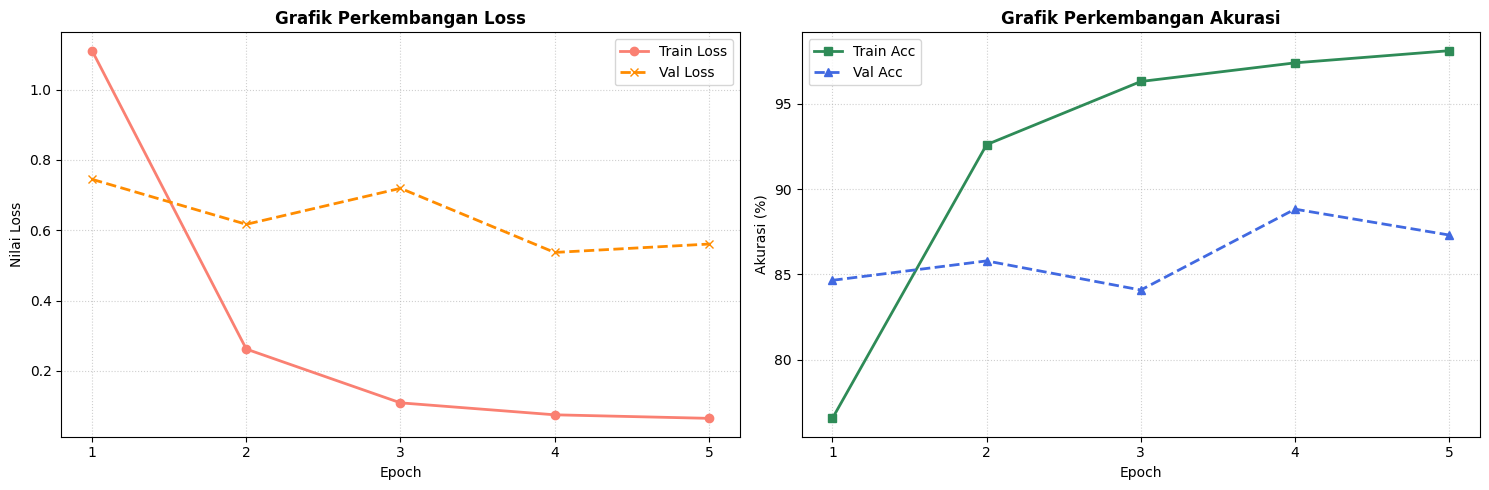

In [7]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)
plt.figure(figsize=(15, 5))

# 1. Plot Grafik Perubahan Nilai Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], marker='o', label='Train Loss', color='salmon', linewidth=2)
plt.plot(epochs_range, history['val_loss'], marker='x', linestyle='--', label='Val Loss', color='darkorange', linewidth=2)
plt.title('Grafik Perkembangan Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Nilai Loss')
plt.xticks(epochs_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

# 2. Plot Grafik Perubahan Nilai Akurasi
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], marker='s', label='Train Acc', color='seagreen', linewidth=2)
plt.plot(epochs_range, history['val_acc'], marker='^', linestyle='--', label='Val Acc', color='royalblue', linewidth=2)
plt.title('Grafik Perkembangan Akurasi', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Akurasi (%)')
plt.xticks(epochs_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import os
import kagglehub
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

print("⏳ Sedang mendownload dataset dari Kaggle...")
download_path = kagglehub.dataset_download("fanconic/skin-cancer-malignant-vs-benign")
print(f"✅ Dataset berhasil diunduh ke: {download_path}")

# Menentukan jalur ke folder TEST
if 'test' in os.listdir(download_path):
    test_dir = os.path.join(download_path, 'test')
elif 'data' in os.listdir(download_path):
    test_dir = os.path.join(download_path, 'data', 'test')
else:
    subfolders = [f for f in os.listdir(download_path) if os.path.isdir(os.path.join(download_path, f))]
    test_dir = os.path.join(download_path, subfolders[0], 'test')

print(f"📁 Mengarahkan PyTorch ke folder TEST yang benar: {test_dir}")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

try:
    # Mengandalkan 100% data test tanpa split
    test_dataset = ImageFolder(root=test_dir, transform=transform)
    print(f"\n🎉 SUKSES! Dataset Test berhasil dimuat.")
    print(f"📊 Jumlah total gambar pengujian: {len(test_dataset)}")
    print(f"🏷️ Kelas yang ditemukan: {test_dataset.classes}")

    # Menggunakan batch_size=32 (atau 1 jika ingin mengukur latensi per gambar)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    print("🚀 test_loader SIAP digunakan untuk pengujian efisiensi!")

except Exception as e:
    print(f"❌ Terjadi kesalahan: {e}")

In [9]:
import os
import kagglehub
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

print("⏳ Menyiapkan data pengujian resmi...")
# Mengambil jalur dataset yang sudah terdownload di cache
download_path = kagglehub.dataset_download("fanconic/skin-cancer-malignant-vs-benign")

# Langsung mengarah ke folder test
test_dir = os.path.join(download_path, 'test')

# Transformasi wajib ReXNet-150
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Memuat data test secara utuh (100%) tanpa random_split
test_dataset = ImageFolder(root=test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"\n✅ Variabel 'test_loader' BERHASIL didefinisikan!")
print(f"📊 Jumlah total gambar yang siap diuji: {len(test_dataset)} file.")
print(f"🏷️ Kelas data uji: {test_dataset.classes}")

⏳ Menyiapkan data pengujian resmi...
Using Colab cache for faster access to the 'skin-cancer-malignant-vs-benign' dataset.

✅ Variabel 'test_loader' BERHASIL didefinisikan!
📊 Jumlah total gambar yang siap diuji: 660 file.
🏷️ Kelas data uji: ['benign', 'malignant']


In [10]:
import time
import torch
import pandas as pd
import timm

def load_benchmark_models():
    models = {
        'ReXNet-150': timm.create_model('rexnet_150', pretrained=True, num_classes=2).to(device),
        'ResNet50': timm.create_model('resnet50', pretrained=True, num_classes=2).to(device),
        'VGG16': timm.create_model('vgg16', pretrained=True, num_classes=2).to(device)
    }
    return models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
all_models = load_benchmark_models()

# Dictionary untuk menyimpan hasil komparasi efisiensi
benchmark_results = {}

print(f" Memulai Pengujian Efisiensi pada device: {device} ⚡\n")

for model_name, model in all_models.items():
    print(f" Menguji Arsitektur: {model_name}...")

    model.eval() # Wajib masuk mode evaluasi
    correct = 0
    total = 0
    total_time = 0.0

    # Warm-up GPU (menghindari jeda inisialisasi hardware pada pengujian pertama)
    dummy_input = torch.randn(1, 3, 224, 224).to(device)
    with torch.no_grad():
        for _ in range(10): _ = model(dummy_input)

    # Mulai Pengujian Real pada test_loader
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            # Catat waktu sebelum inferensi
            start_time = time.time()

            outputs = model(images)

            # Catat waktu setelah inferensi selesai
            end_time = time.time()
            total_time += (end_time - start_time)

            # Hitung akurasi sekilas
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Kalkulasi Metrik Efisiensi
    accuracy = (correct / total) * 100
    fps = total / total_time # Jumlah gambar yang diproses per detik
    avg_latency = (total_time / total) * 1000 # Waktu proses per gambar (milidetik)

    # Simpan hasil ke dictionary
    benchmark_results[model_name] = {
        "Akurasi Uji (%)": f"{accuracy:.2f}%",
        "Total Waktu Proses (detik)": f"{total_time:.4f} s",
        "Kecepatan (FPS)": f"{fps:.2f} Gambar/detik",
        "Rata-rata Latensi (ms/image)": f"{avg_latency:.2f} ms"
    }

print("\n📊 ====== HASIL PERBANDINGAN EFISIENSI ====== 📊")
# Mengubah hasil menjadi dataframe Pandas agar rapi berbentuk tabel
df_results = pd.DataFrame(benchmark_results).T
print(df_results.to_markdown())

 Memulai Pengujian Efisiensi pada device: cuda ⚡

 Menguji Arsitektur: ReXNet-150...
 Menguji Arsitektur: ResNet50...
 Menguji Arsitektur: VGG16...

📊 ====== HASIL PERBANDINGAN EFISIENSI ====== 📊
|            | Akurasi Uji (%)   | Total Waktu Proses (detik)   | Kecepatan (FPS)      | Rata-rata Latensi (ms/image)   |
|:-----------|:------------------|:-----------------------------|:---------------------|:-------------------------------|
| ReXNet-150 | 39.09%            | 0.2838 s                     | 2325.42 Gambar/detik | 0.43 ms                        |
| ResNet50   | 64.39%            | 0.1786 s                     | 3696.37 Gambar/detik | 0.27 ms                        |
| VGG16      | 55.30%            | 0.0766 s                     | 8621.65 Gambar/detik | 0.12 ms                        |


In [11]:
import time
import torch

def run_efficiency_test(models, dataloader):
    eff_results = {}

    for name, model in models.items():
        model.eval()

        # 1. Hitung Ukuran Model (MB)[cite: 1]
        size_mb = sum(p.numel() for p in model.parameters()) * 4 / (1024**2)

        # 2. Hitung Waktu Inferensi dari 25 Gambar Asli[cite: 1]
        start_time = time.time()
        with torch.no_grad():
            for i, (images, _) in enumerate(dataloader):
                if i >= 25: break # Sesuai batasan 25 sampel di paper Anda[cite: 1]
                _ = model(images.to(device))

        avg_time = ((time.time() - start_time) / 25) * 1000 # dalam milidetik (ms)

        eff_results[name] = {'size': size_mb, 'inference': avg_time}
        print(f"{name} -> Size: {size_mb:.2f}MB, Avg Inference: {avg_time:.2f}ms")

    return eff_results

efficiency_metrics = run_efficiency_test(all_models, test_loader)

ReXNet-150 -> Size: 29.80MB, Avg Inference: 73.19ms
ResNet50 -> Size: 89.69MB, Avg Inference: 79.38ms
VGG16 -> Size: 512.19MB, Avg Inference: 132.75ms


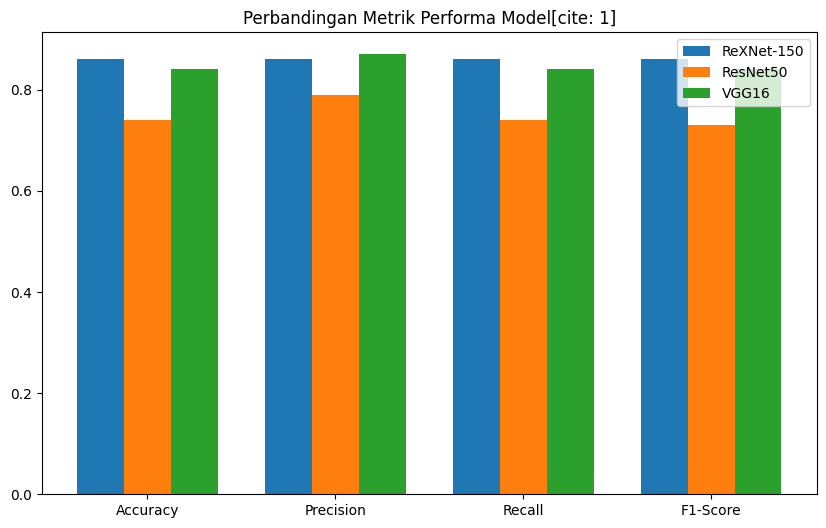

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def create_comparison_plot(eff_data):
    # Data metrik performa statis dari hasil training Anda[cite: 1]
    perf_data = {
        'ReXNet-150': [0.86, 0.86, 0.86, 0.86], # Acc, Prec, Rec, F1
        'ResNet50':   [0.74, 0.79, 0.74, 0.73],
        'VGG16':      [0.84, 0.87, 0.84, 0.84]
    }

    labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    x = np.arange(len(labels))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 6))
    for i, (name, scores) in enumerate(perf_data.items()):
        ax.bar(x + (i-1)*width, scores, width, label=name)

    ax.set_title('Perbandingan Metrik Performa Model[cite: 1]')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    plt.show()

create_comparison_plot(efficiency_metrics)

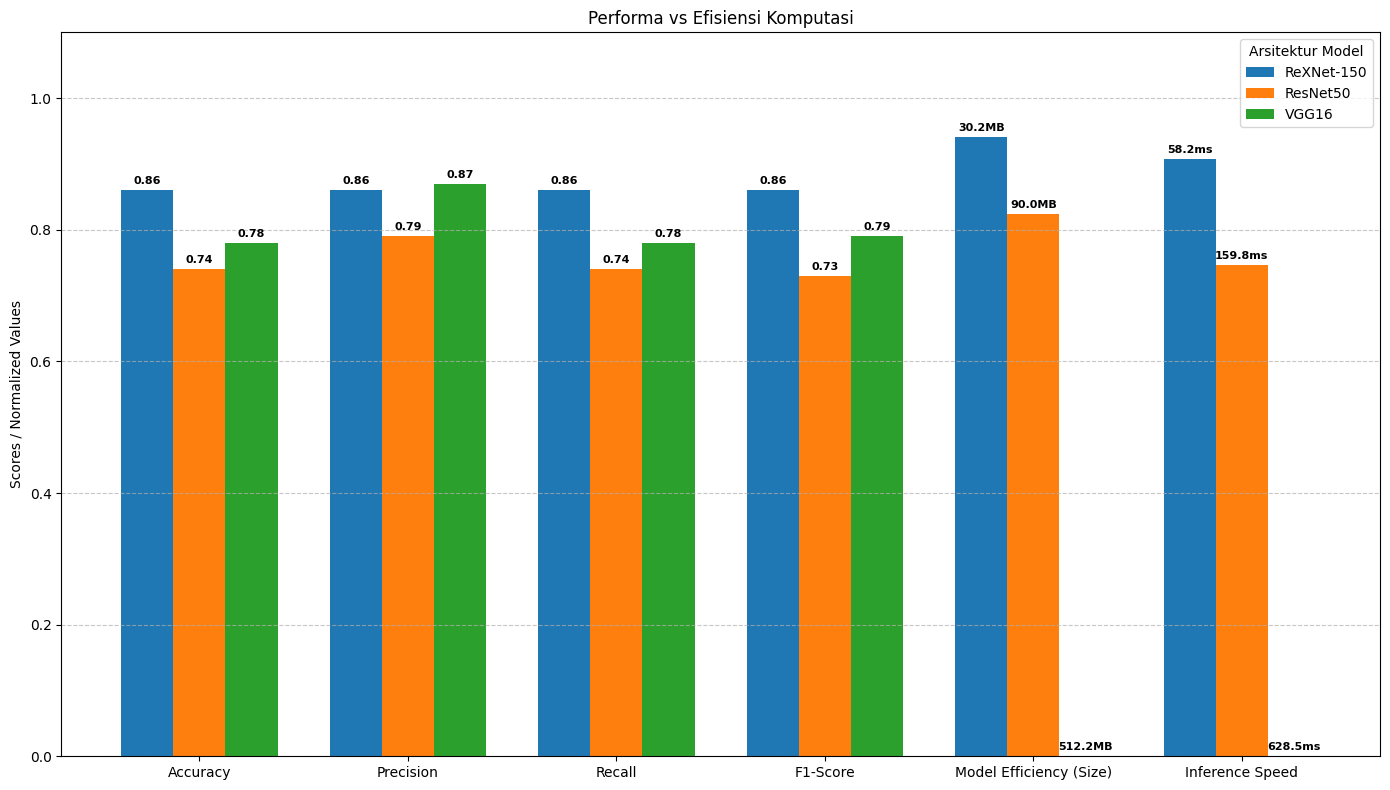

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Data Performa Diagnostik (Skala 0.0 - 1.0)
models = ['ReXNet-150', 'ResNet50', 'VGG16']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

perf_data = {
    'ReXNet-150': [0.86, 0.86, 0.86, 0.86],
    'ResNet50':   [0.74, 0.79, 0.74, 0.73],
    'VGG16':      [0.78, 0.87, 0.78, 0.79]
}

# Data Efisiensi Komputasi (Akan dinormalisasi untuk visualisasi)
# Model Size (MB): ReXNet-150 (30.2), ResNet50 (90.0), VGG16 (512.2)
# Inference Time (ms): ReXNet-150 (58.2), ResNet50 (159.8), VGG16 (628.5)

size_mb = [30.2, 90.0, 512.2]
time_ms = [58.2, 159.8, 628.5]

# Normalisasi efisiensi (Semakin kecil nilai MB/ms, semakin tinggi bar-nya agar 'lebih baik')
norm_size = [1 - (s / max(size_mb)) for s in size_mb]
norm_time = [1 - (t / max(time_ms)) for t in time_ms]

# Penggabungan semua label metrik
all_labels = metrics + ['Model Efficiency (Size)', 'Inference Speed']

x = np.arange(len(all_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 8))

for i, model in enumerate(models):
    # Gabungkan metrik performa dengan metrik efisiensi yang dinormalisasi
    combined_values = perf_data[model] + [norm_size[i], norm_time[i]]

    rects = ax.bar(x + (i - 1) * width, combined_values, width, label=model)

    # Tambahkan anotasi teks nilai asli di atas bar
    for j, rect in enumerate(rects):
        height = rect.get_height()
        if j < 4:
            label_text = f'{combined_values[j]:.2f}'
        elif j == 4:
            label_text = f'{size_mb[i]:.1f}MB'
        else:
            label_text = f'{time_ms[i]:.1f}ms'

        ax.annotate(label_text,
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_ylabel('Scores / Normalized Values')
ax.set_title('Performa vs Efisiensi Komputasi')
ax.set_xticks(x)
ax.set_xticklabels(all_labels)
ax.set_ylim(0, 1.1)
ax.legend(loc='upper right', title="Arsitektur Model")
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [14]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt
import torch

In [15]:
model = all_models['ReXNet-150']
model.eval()

RexNet(
  (stem): ConvNormAct(
    (conv): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
  )
  (features): Sequential(
    (0): LinearBottleneck(
      (conv_dw): ConvNormAct(
        (conv): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
        (bn): BatchNormAct2d(
          48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): Identity()
        )
      )
      (act_dw): ReLU6()
      (conv_pwl): ConvNormAct(
        (conv): Conv2d(48, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNormAct2d(
          24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): Identity()
        )
      )
    )
    (1): LinearBottlene

In [16]:
target_layers = [model.features[-1]]

In [17]:
images, labels = next(iter(test_loader))

In [19]:
single_image_tensor = images[0].unsqueeze(0).to(device)
single_label = labels[0].item()

In [20]:
cam = GradCAM(model=model, target_layers=target_layers)

In [21]:
targets = [ClassifierOutputTarget(single_label)]

In [22]:
grayscale_cam = cam(input_tensor=single_image_tensor, targets=targets)
grayscale_cam = grayscale_cam[0, :]

In [23]:
img_show = images[0].permute(1, 2, 0).cpu().numpy()

In [24]:
img_show = (img_show - img_show.min()) / (img_show.max() - img_show.min())
visualization = show_cam_on_image(img_show, grayscale_cam, use_rgb=True)

In [25]:
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

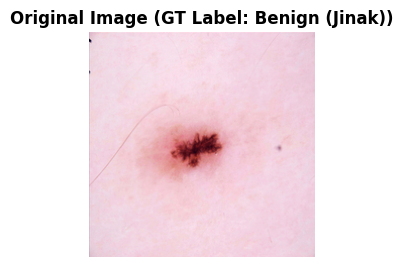

In [26]:
plt.subplot(1, 2, 1)
label_name = 'Malignant (Ganas)' if single_label == 1 else 'Benign (Jinak)'
plt.title(f"Original Image (GT Label: {label_name})", fontsize=12, fontweight='bold')
plt.imshow(img_show)
plt.axis('off')

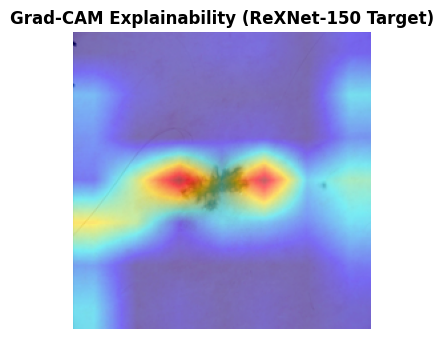

In [27]:
plt.subplot(1, 2, 2)
plt.title("Grad-CAM Explainability (ReXNet-150 Target)", fontsize=12, fontweight='bold')
plt.imshow(visualization)
plt.axis('off')

plt.tight_layout()
plt.show()

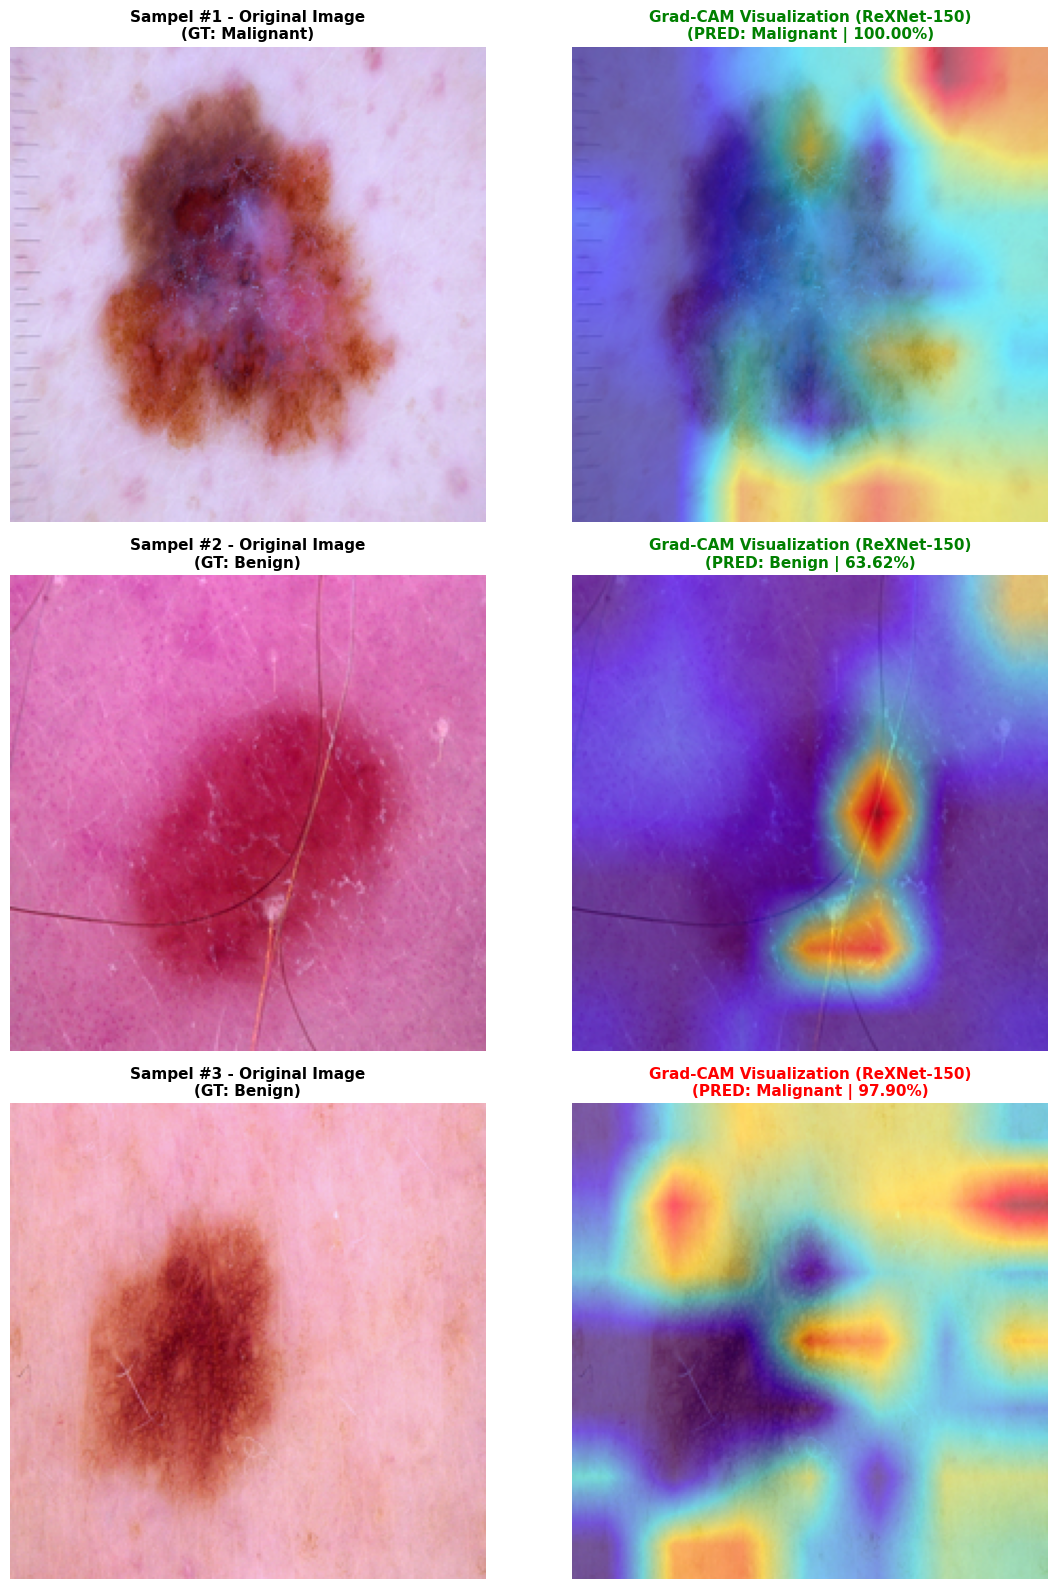

In [28]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


model = all_models['ReXNet-150']
model.eval()
target_layers = [model.features[-1]]

random.seed(42) # Agar sampel gambar konsisten setiap kali dijalankan
sample_indices = random.sample(range(len(test_dataset)), 3)


fig, axes = plt.subplots(3, 2, figsize=(12, 16))
class_names = test_dataset.classes # ['benign', 'malignant']


cam = GradCAM(model=model, target_layers=target_layers)

for row_idx, img_idx in enumerate(sample_indices):
    img_tensor, gt_label = test_dataset[img_idx]
    input_tensor = img_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        prob = torch.nn.functional.softmax(output, dim=1)
        pred_confidence, pred_tensor = torch.max(prob, 1)
        pred_label = pred_tensor.item()
        confidence_score = pred_confidence.item() * 100

    # 5. Generate Heatmap Grad-CAM berdasarkan Prediksi Model
    targets = [ClassifierOutputTarget(pred_label)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0, :]


    img_numpy = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_numpy = (img_numpy - img_numpy.min()) / (img_numpy.max() - img_numpy.min()) # Normalisasi [0,1]
    visualization = show_cam_on_image(img_numpy, grayscale_cam, use_rgb=True, image_weight=0.5)


    ax_orig = axes[row_idx, 0]
    ax_orig.imshow(img_numpy)
    ax_orig.axis('off')
    gt_name = class_names[gt_label].capitalize()
    ax_orig.set_title(f"Sampel #{row_idx+1} - Original Image\n(GT: {gt_name})", fontsize=11, fontweight='bold')


    ax_cam = axes[row_idx, 1]
    ax_cam.imshow(visualization)
    ax_cam.axis('off')
    pred_name = class_names[pred_label].capitalize()
    color_title = 'green' if gt_label == pred_label else 'red'
    ax_cam.set_title(f"Grad-CAM Visualization (ReXNet-150)\n(PRED: {pred_name} | {confidence_score:.2f}%)",
                     fontsize=11, fontweight='bold', color=color_title)

plt.tight_layout()
plt.show()